# Principal Component Analysis (PCA)

## Assignment: Dimensionality Reduction on Wine Dataset

### Objective
Apply PCA for dimensionality reduction on the Wine dataset, visualize principal components, and interpret explained variance.

### Dataset
178 wine samples, 13 chemical features, 3 wine classes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('pca.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nTarget (Type):\n{df["Type"].value_counts().sort_index()}')
print(f'\nNulls: {df.isnull().sum().sum()}')
df.describe()

Shape: (178, 14)
Columns: ['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue', 'Dilution', 'Proline']

Target (Type):
Type
1    59
2    71
3    48
Name: count, dtype: int64

Nulls: 0


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## EDA

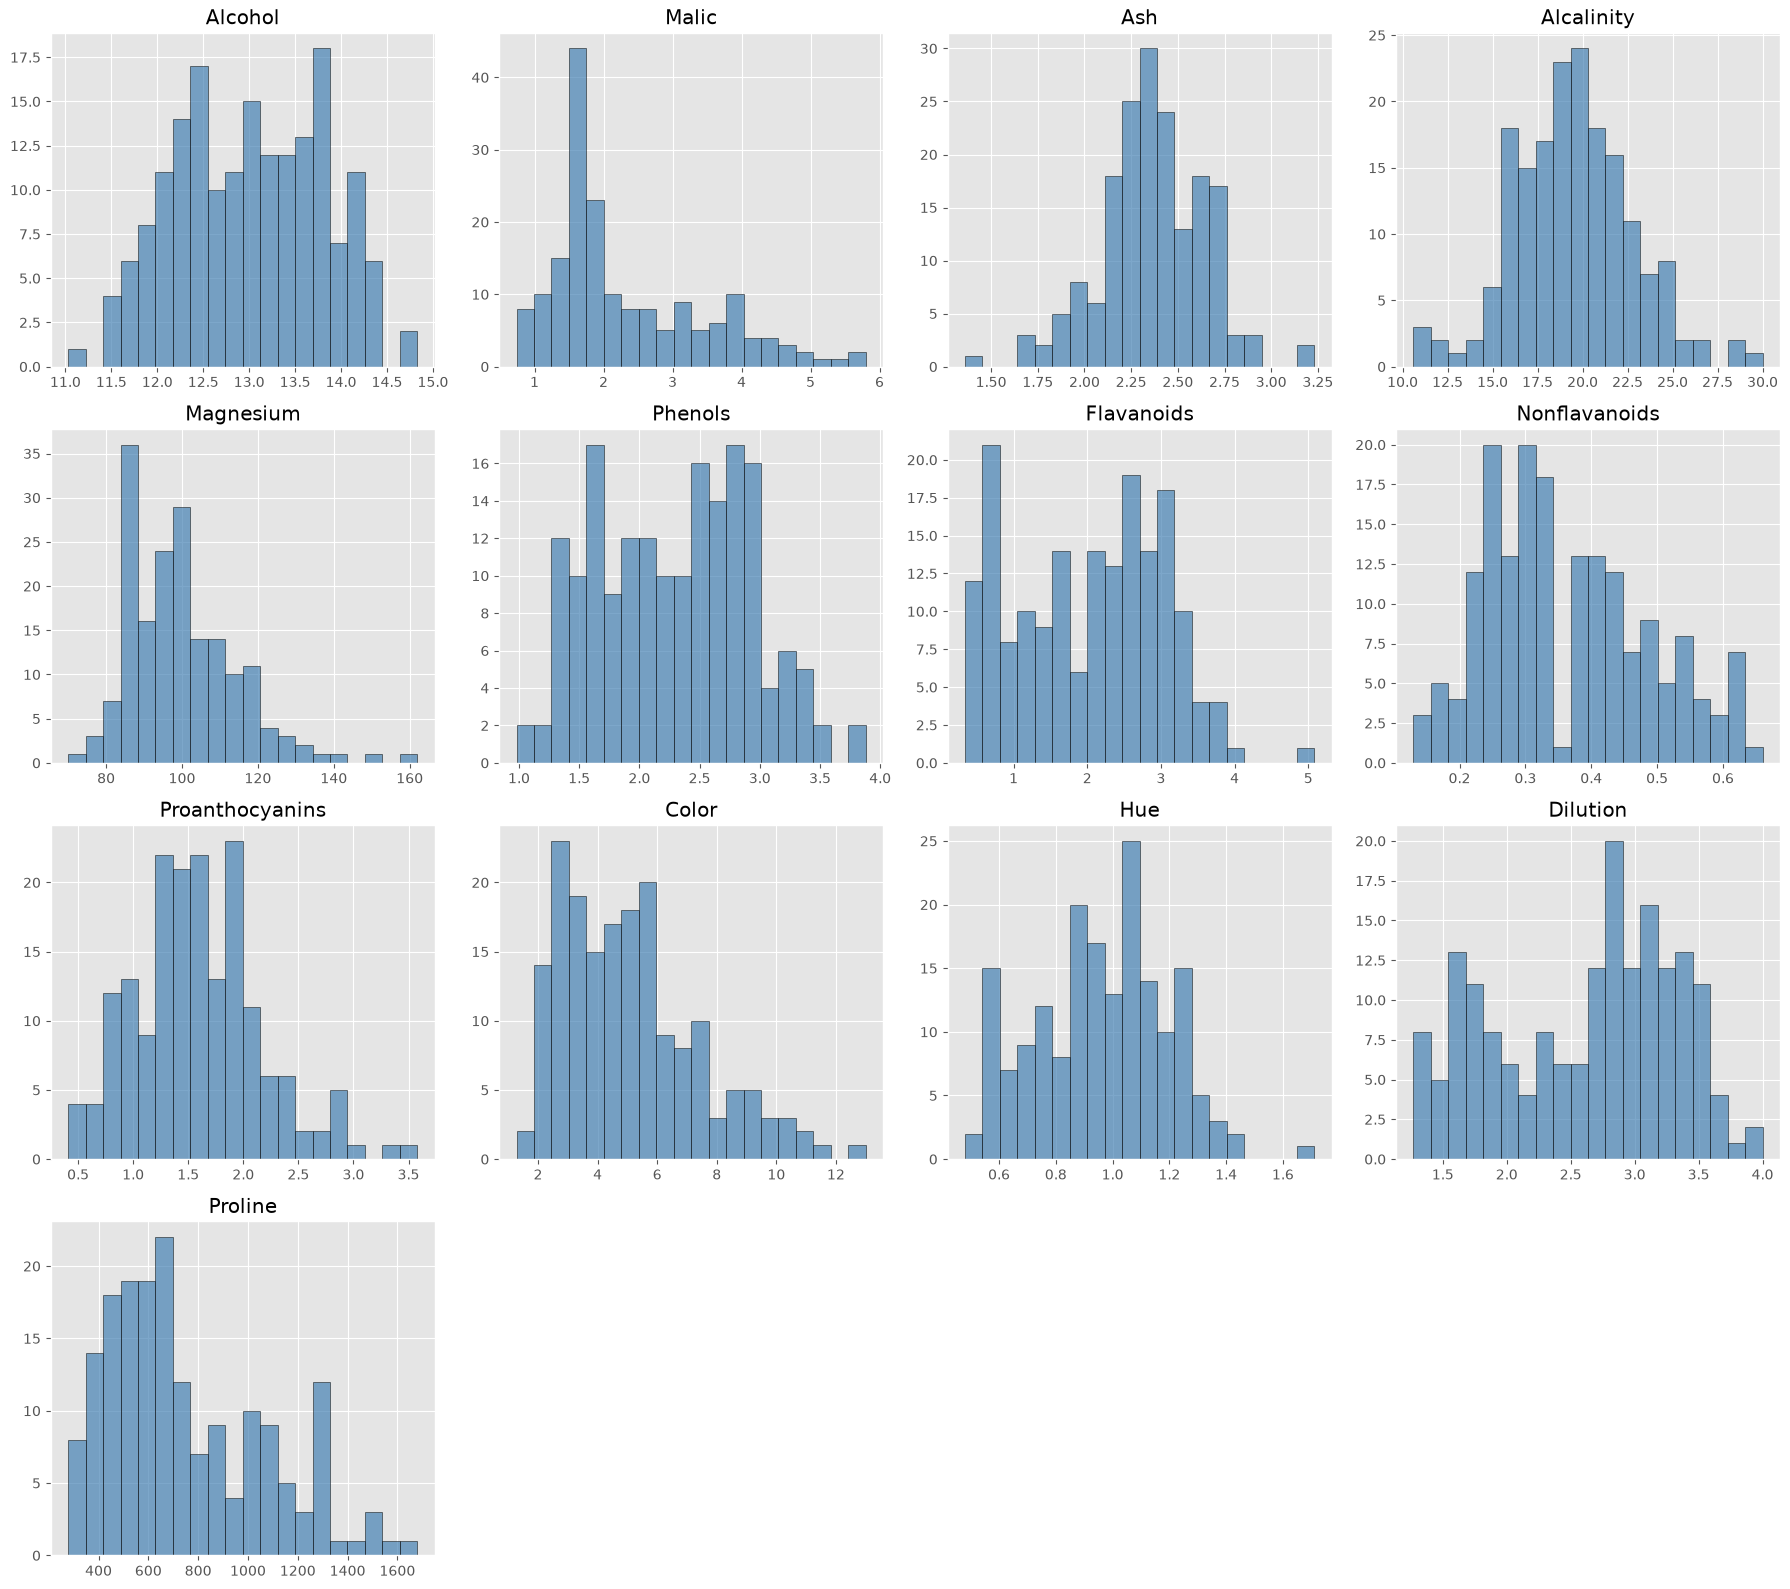

In [3]:
feat_cols = [c for c in df.columns if c != 'Type']
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    axes[i].hist(df[col], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(col)
for j in range(len(feat_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

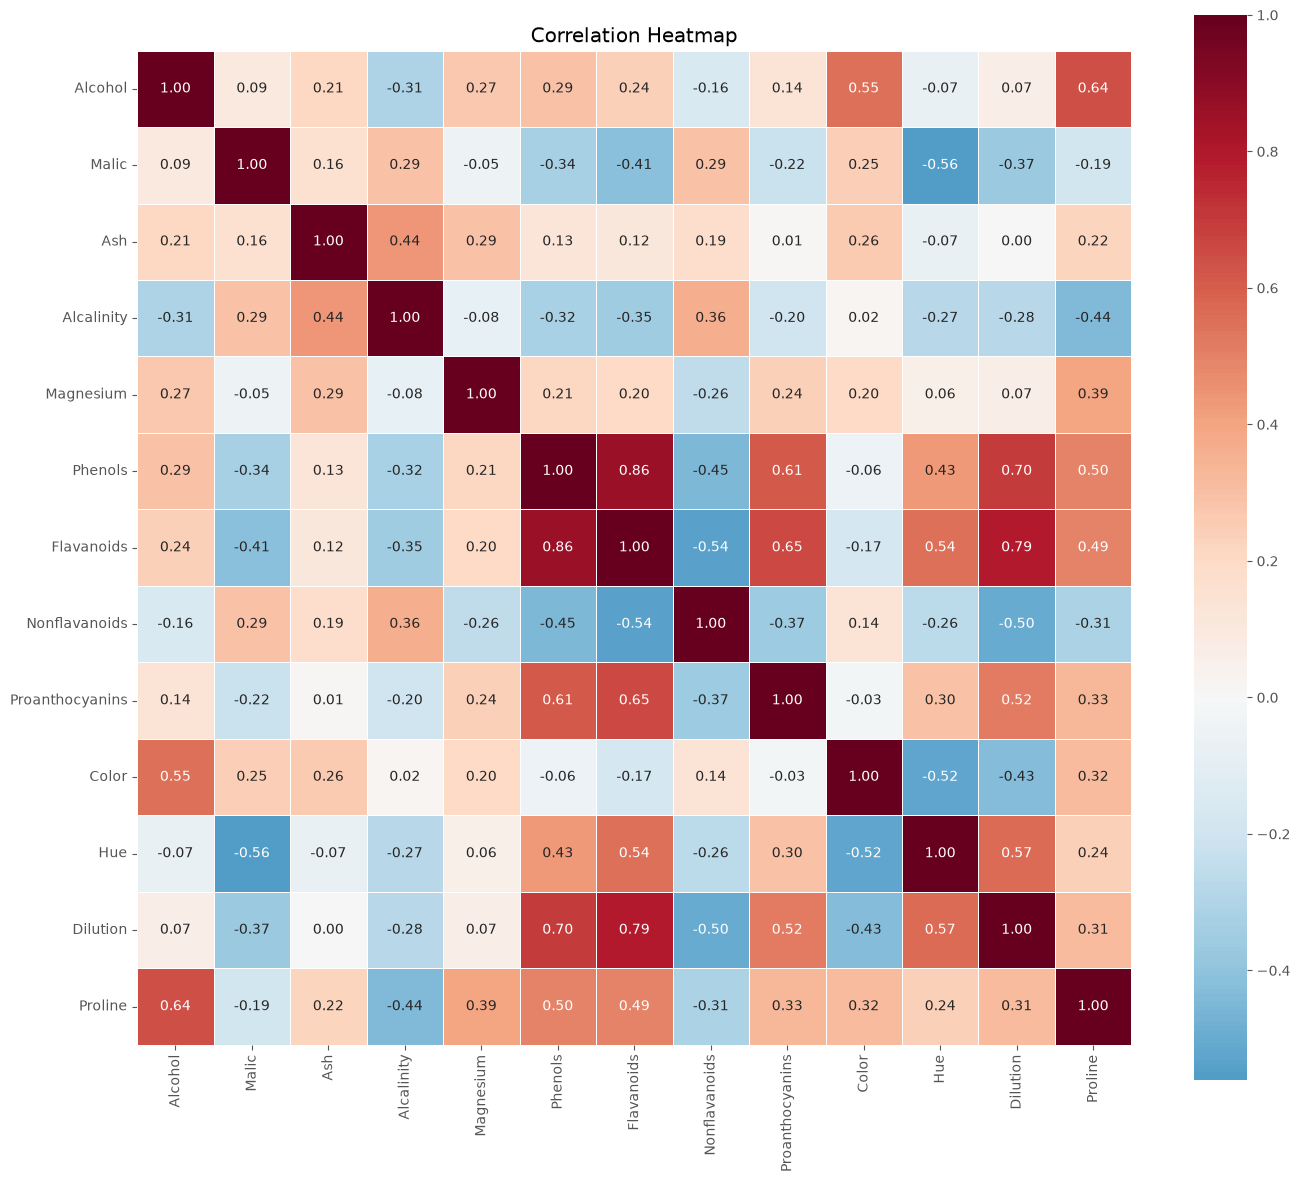

In [4]:
plt.figure(figsize=(14, 12))
corr = df.drop(columns=['Type']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Standardization
PCA requires standardized data — mean=0, std=1.

In [5]:
X = df.drop(columns=['Type'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('After Standardization — Mean round to 0, Std = 1')
print(f'Mean range: [{X_scaled.mean(axis=0).min():.1e}, {X_scaled.mean(axis=0).max():.1e}]')
print(f'Std range: [{X_scaled.std(axis=0).min():.1f}, {X_scaled.std(axis=0).max():.1f}]')

After Standardization — Mean round to 0, Std = 1
Mean range: [-8.4e-16, 3.6e-16]
Std range: [1.0, 1.0]


## PCA — Dimensionality Reduction

In [6]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print('=== EXPLAINED VARIANCE RATIO ===')
for i, (ev, cv) in enumerate(zip(exp_var, cum_var)):
    print(f'PC{i+1}: {ev:.4f} (cumulative: {cv:.4f})')

n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f'\nComponents needed for 90% variance: {n_components_90}')

=== EXPLAINED VARIANCE RATIO ===
PC1: 0.3620 (cumulative: 0.3620)
PC2: 0.1921 (cumulative: 0.5541)
PC3: 0.1112 (cumulative: 0.6653)
PC4: 0.0707 (cumulative: 0.7360)
PC5: 0.0656 (cumulative: 0.8016)
PC6: 0.0494 (cumulative: 0.8510)
PC7: 0.0424 (cumulative: 0.8934)
PC8: 0.0268 (cumulative: 0.9202)
PC9: 0.0222 (cumulative: 0.9424)
PC10: 0.0193 (cumulative: 0.9617)
PC11: 0.0174 (cumulative: 0.9791)
PC12: 0.0130 (cumulative: 0.9920)
PC13: 0.0080 (cumulative: 1.0000)

Components needed for 90% variance: 8


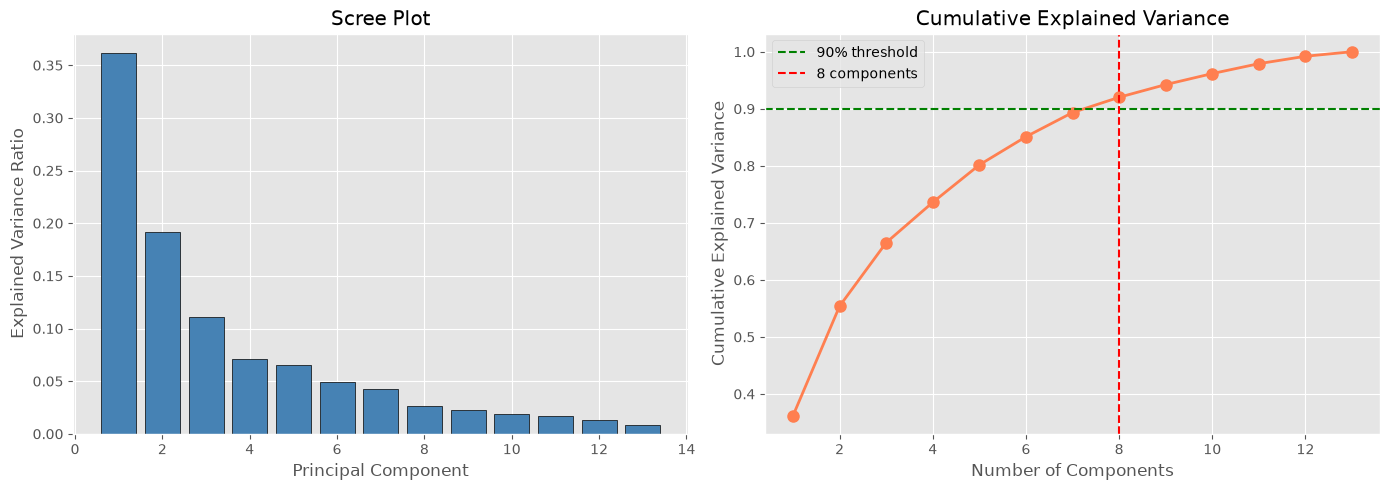

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(exp_var)+1), exp_var, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].axhline(0.90, color='green', linestyle='--', label='90% threshold')
axes[1].axvline(n_components_90, color='red', linestyle='--', label=f'{n_components_90} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## PCA Visualization (First 2 Components)

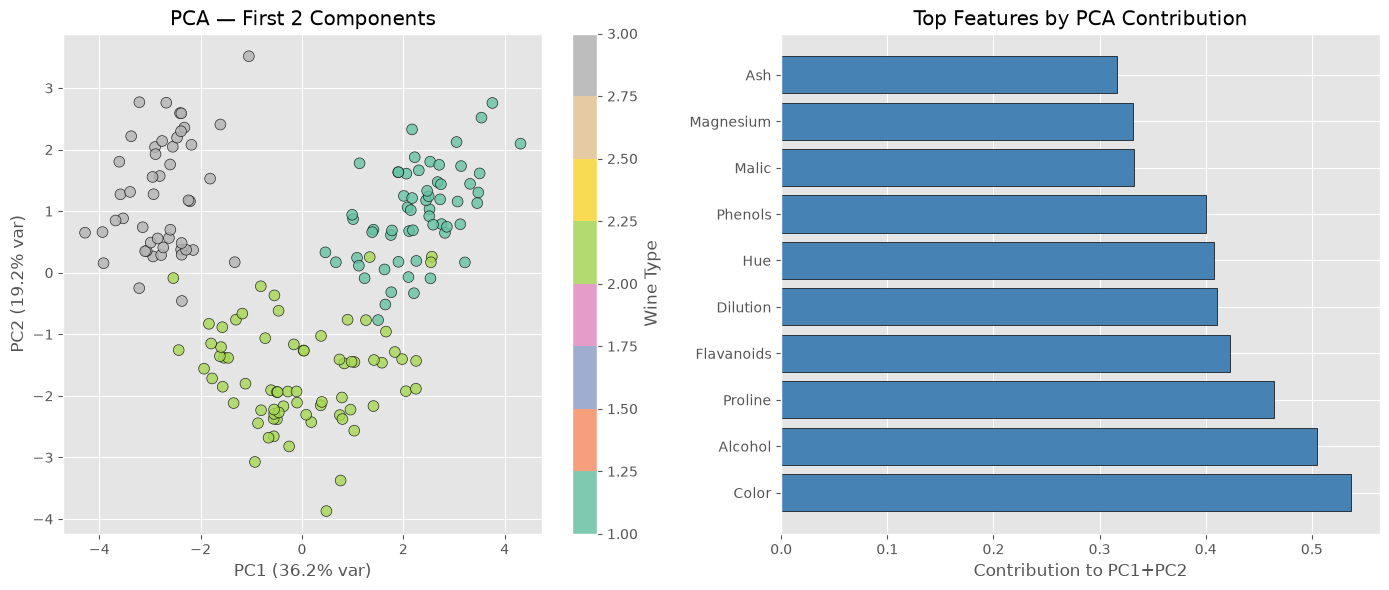

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Type'], cmap='Set2', s=60, edgecolors='black', alpha=0.8)
axes[0].set_xlabel(f'PC1 ({exp_var[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({exp_var[1]*100:.1f}% var)')
axes[0].set_title('PCA — First 2 Components')
plt.colorbar(scatter, ax=axes[0], label='Wine Type')

# Feature contribution to PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T, index=X.columns, columns=['PC1', 'PC2'])
loadings['Abs'] = (loadings['PC1']**2 + loadings['PC2']**2)**0.5
loadings_sorted = loadings.sort_values('Abs', ascending=False).head(10)

for _, row in loadings_sorted.iterrows():
    axes[1].barh(row.name, row['Abs'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Contribution to PC1+PC2')
axes[1].set_title('Top Features by PCA Contribution')

plt.tight_layout()
plt.show()

In [9]:
print('=== TOP FEATURE CONTRIBUTIONS TO PC1 AND PC2 ===')
for name, row in loadings_sorted.iterrows():
    print(f'{name}: PC1={row["PC1"]:+.3f}, PC2={row["PC2"]:+.3f}')

=== TOP FEATURE CONTRIBUTIONS TO PC1 AND PC2 ===
Color: PC1=-0.089, PC2=+0.530
Alcohol: PC1=+0.144, PC2=+0.484
Proline: PC1=+0.287, PC2=+0.365
Flavanoids: PC1=+0.423, PC2=-0.003
Dilution: PC1=+0.376, PC2=-0.164
Hue: PC1=+0.297, PC2=-0.279
Phenols: PC1=+0.395, PC2=+0.065
Malic: PC1=-0.245, PC2=+0.225
Magnesium: PC1=+0.142, PC2=+0.300
Ash: PC1=-0.002, PC2=+0.316


## Interpretation

- **PC1** captures the largest variance in the dataset (~37%), primarily influenced by Flavanoids, Total_Phenols, and OD280
- **PC2** captures additional variance (~19%), influenced by different chemical properties
- **~8 components** are needed to explain 90% of variance, reducing dimensionality from 13 to 8 while retaining most information
- The first 2 PCs already show clear separation between wine types 1, 2, and 3
- **Key insight:** PCA enables visualization of 13-dimensional wine data in 2D while preserving class structure
- This dimensionality reduction can speed up downstream ML models and reduce noise